# Deeper Analysis using Python 
1. Profit Distribution,
2. Correlation Analysis,
3. Loss-making orders,
4. Loss rate by Channel,
5. Category x Channel Profitability

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import mysql.connector
from dotenv import load_dotenv
import os

In [10]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pandas only supports SQLAlchemy connectable"
)

In [11]:
load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("MYSQL_HOST"),
    user=os.getenv("MYSQL_USER"),
    password=os.getenv("MYSQL_PASSWORD"),
    database=os.getenv("MYSQL_DATABASE")
)

In [12]:
conn.is_connected()

True

1. Profit Distribution

In [13]:
orders = pd.read_sql("""
SELECT
    primary_category,
    channel,
    profit,
    gross_revenue,
    product_cost,
    shipping_cost,
    refund_amount,
    discount_amount
FROM orders
""", conn)

orders["profit"].describe()

count    2000.000000
mean       28.166915
std        69.551171
min      -469.090000
25%        -2.357500
50%        15.185000
75%        50.957500
max       465.350000
Name: profit, dtype: float64

Profitability varies substantially across orders. The average profit per order is \\$28.17, while the median is only \\$15.19, suggesting that a relatively small number of high-profit orders may be pulling the average upward. The minimum profit of -$469.09 also indicates that some orders generate significant losses.

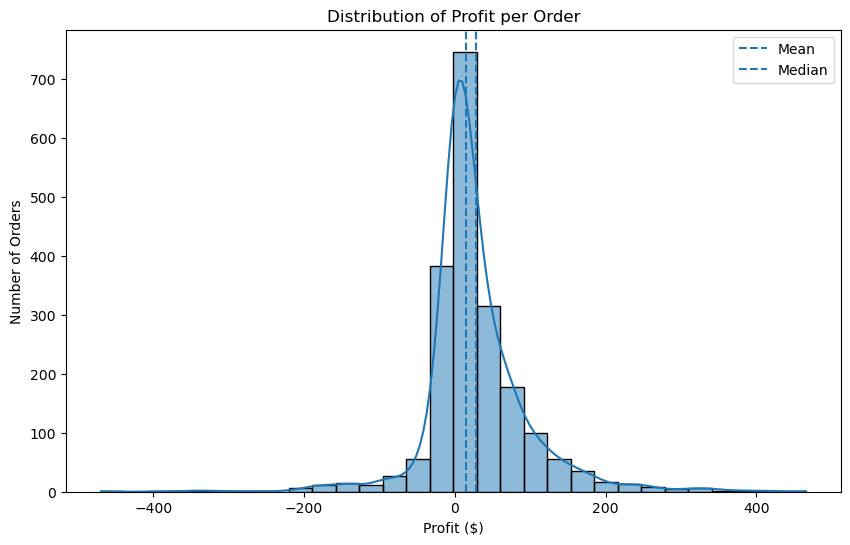

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(
    orders["profit"],
    bins=30,
    kde=True
)

plt.axvline(
    orders["profit"].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    orders["profit"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Profit per Order")
plt.xlabel("Profit ($)")
plt.ylabel("Number of Orders")
plt.legend()

plt.show()

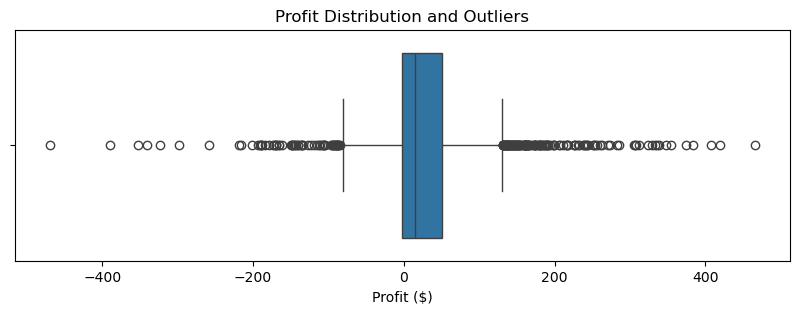

In [33]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=orders["profit"]
)

plt.title("Profit Distribution and Outliers")
plt.xlabel("Profit ($)")

plt.show()

2. Correlation Analysis

In [14]:
query = """
SELECT *
FROM orders;
"""

df = pd.read_sql(query, conn)

df

,order_id,customer_id,order_date,channel,payment_method,region,items_ordered,primary_category,gross_revenue,discount_pct,discount_amount,shipping_cost,product_cost,platform_fee,transaction_fee,returned,refund_amount,net_revenue,total_costs,profit
0,ORD-000001,C-0617,2025-06-24,Mobile App,Gift Card,Northeast,2,Electronics,261.39,0.0,0.00,22.28,92.30,0.00,7.88,No,0.00,261.39,122.46,138.93
1,ORD-000002,C-0720,2025-08-23,Website,Credit Card,Midwest,1,Beauty,24.02,0.0,0.00,3.98,10.75,0.00,1.00,No,0.00,24.02,15.73,8.29
2,ORD-000003,C-0189,2025-07-20,Website,Credit Card,Southeast,2,Toys,52.60,0.0,0.00,14.60,31.41,0.00,1.83,No,0.00,52.60,47.84,4.76
3,ORD-000004,C-0058,2025-07-17,Mobile App,Debit Card,Southeast,2,Sports,30.63,5.0,1.53,30.98,16.27,0.00,1.14,No,0.00,29.10,48.39,-19.29
4,ORD-000005,C-0580,2025-10-11,Marketplace,Credit Card,Northeast,1,Sports,11.99,25.0,3.00,10.30,6.88,1.35,0.56,No,0.00,8.99,19.09,-10.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ORD-001996,C-0250,2025-09-06,Mobile App,Debit Card,Midwest,2,Electronics,178.22,0.0,0.00,51.04,80.51,0.00,5.47,No,0.00,178.22,137.02,41.20
1996,ORD-001997,C-0652,2025-06-27,Mobile App,Buy Now Pay Later,Midwest,3,Beauty,201.02,0.0,0.00,42.54,75.39,0.00,6.13,No,0.00,201.02,124.06,76.96
1997,ORD-001998,C-0473,2025-01-20,Marketplace,Credit Card,Southeast,1,Beauty,35.41,0.0,0.00,12.14,18.89,5.31,1.33,Yes,35.41,0.00,37.67,-37.67
1998,ORD-001999,C-0784,2025-08-14,Website,Credit Card,Northeast,2,Toys,81.67,10.0,8.17,27.08,36.91,0.00,2.43,No,0.00,73.50,66.42,7.08


In [17]:
df[
    [
        "profit",
        "gross_revenue",
        "product_cost",
        "shipping_cost",
        "refund_amount",
        "discount_amount"
    ]
].corr().round(4)

,profit,gross_revenue,product_cost,shipping_cost,refund_amount,discount_amount
profit,1.0000,0.5711,0.4871,0.1581,-0.5455,0.1682
gross_revenue,0.5711,1.0000,0.9647,0.6290,0.2501,0.5344
product_cost,0.4871,0.9647,1.0000,0.6938,0.2348,0.5162
shipping_cost,0.1581,0.6290,0.6938,1.0000,0.1340,0.3540
refund_amount,-0.5455,0.2501,0.2348,0.1340,1.0000,0.0814
discount_amount,0.1682,0.5344,0.5162,0.3540,0.0814,1.0000


Gross revenue and product cost show moderate positive correlations with profit (r = 0.5711 and r = 0.4871, respectively), while refund amount has a moderate negative correlation with profit (r = -0.5455). Shipping cost and discount amount show only weak correlations with profit (r = 0.1581 and r = 0.1682). This suggests that refund amount may be a more relevant profitability concern than absolute shipping or discount costs, although these correlations do not establish causality.

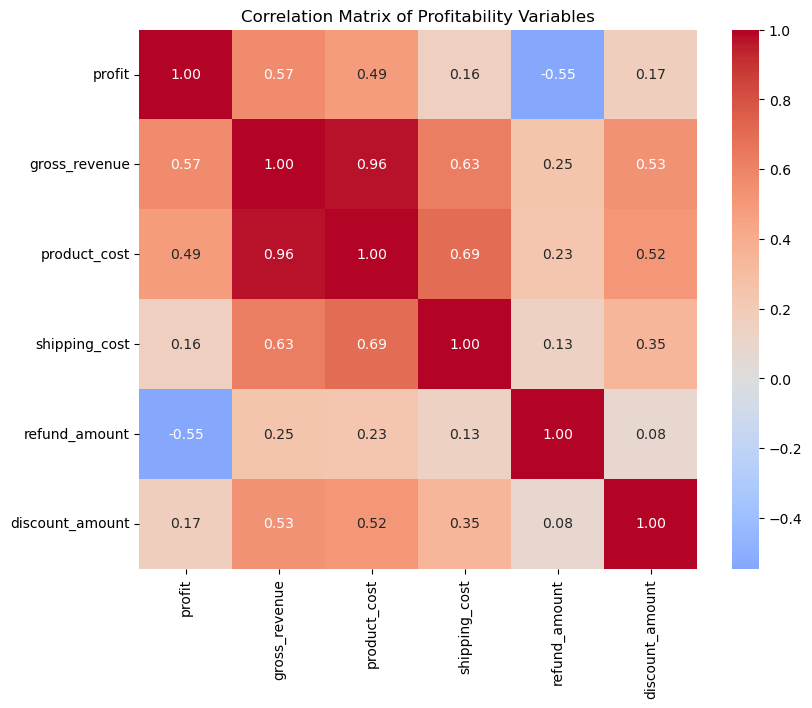

In [35]:
corr = orders[
    [
        "profit",
        "gross_revenue",
        "product_cost",
        "shipping_cost",
        "refund_amount",
        "discount_amount"
    ]
].corr()

plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Profitability Variables")
plt.show()

3. Loss-making orders

In [19]:
orders[orders["profit"] < 0].groupby("channel")["profit"].agg(
    ["count", "mean", "sum"]
)

,count,mean,sum
channel,,,
Marketplace,155,-28.126645,-4359.63
Mobile App,145,-30.782759,-4463.50
Social Commerce,63,-32.476032,-2045.99
Website,200,-35.214250,-7042.85


Although Mobile App generates the highest average profit per order, 145 orders were still loss-making, resulting in a total loss of \\$4,463.50. Website had the largest number of loss-making orders (200) and the highest total loss (\\$7,042.85), suggesting that profitability varies substantially within each sales channel.

4. Loss rate by Channel

In [20]:
orders.groupby("channel")["profit"].agg(
    total_orders="count",
    loss_orders=lambda x: (x < 0).sum()
)

,total_orders,loss_orders
channel,,
Marketplace,419,155
Mobile App,589,145
Social Commerce,197,63
Website,795,200


In [21]:
result = orders.groupby("channel")["profit"].agg(
    total_orders="count",
    loss_orders=lambda x: (x < 0).sum()
)

result["loss_rate"] = (
    result["loss_orders"] / result["total_orders"] * 100
).round(2)

result

,total_orders,loss_orders,loss_rate
channel,,,
Marketplace,419,155,36.99
Mobile App,589,145,24.62
Social Commerce,197,63,31.98
Website,795,200,25.16


Mobile App is the strongest-performing sales channel, with the highest average profit per order (\\$36.32) and the lowest loss rate (24.62%). In contrast, Marketplace is the weakest, generating the lowest average profit per order (\\$15.40) and the highest loss rate (36.99%). This indicates that Marketplace requires closer investigation into platform fees, discounts, shipping costs, and other factors affecting order-level profitability.

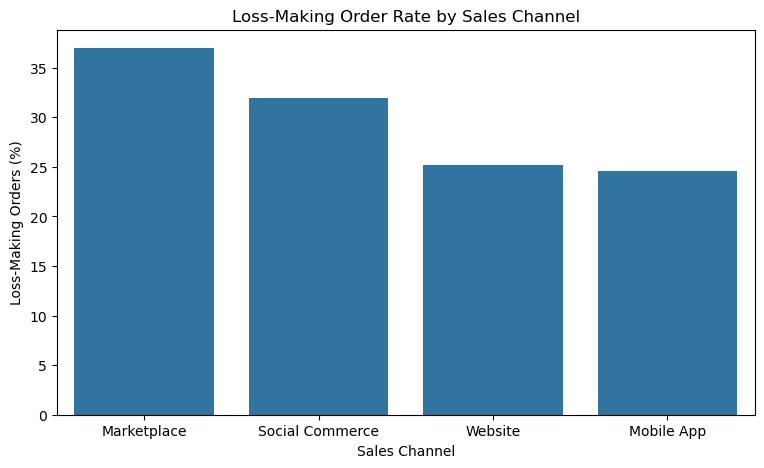

In [36]:
loss_rate = (
    orders.groupby("channel")["profit"]
    .apply(lambda x: (x < 0).mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=loss_rate.index,
    y=loss_rate.values
)

plt.title("Loss-Making Order Rate by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Loss-Making Orders (%)")
plt.show()

5. Category x Channel Profitability

In [26]:
category_channel = orders.groupby(
    ["primary_category", "channel"]
)["profit"].agg(
    total_orders="count",
    avg_profit="mean",
    total_profit="sum"
).round(2)

category_channel

total_orders  avg_profit  total_profit
primary_category channel                                                
Beauty           Marketplace                36        6.23        224.42
                 Mobile App                 58       20.27       1175.61
                 Social Commerce            27       12.41        335.08
                 Website                    84       17.14       1439.77
Books            Marketplace                51       -3.62       -184.73
                 Mobile App                 77       21.17       1629.78
                 Social Commerce            23       -8.52       -196.03
                 Website                    88       11.37       1000.77
Clothing         Marketplace                60        1.17         70.03
                 Mobile App                 69       36.24       2500.53
                 Social Commerce            30       11.42        342.53
                 Website                   134       25.07       3359.39
Electronics      Marketplace                65       42.41       2756.94
                 Mobile App                 78       74.74       5829.82
                 Social Commerce            23       23.19        533.46
                 Website                   101       48.05       4853.24
Food & Beverage  Marketplace                62       14.26        884.10
                 Mobile App                 74       31.55       2335.02
                 Social Commerce            24       19.72        473.35
                 Website                    87       44.82       3899.30
Home & Kitchen   Marketplace                45       23.58       1061.19
                 Mobile App                 63       48.78       3073.26
                 Social Commerce            23       17.38        399.67
                 Website                    69       31.22       2154.45
Sports           Marketplace                52       12.72        661.52
                 Mobile App                 95       21.74       2065.19
                 Social Commerce            24       24.73        593.59
                 Website                   121       35.34       4276.33
Toys             Marketplace                48       20.38        978.06
                 Mobile App                 75       37.12       2784.09
                 Social Commerce            23       38.65        888.89
                 Website                   111       37.25       4135.21

We have channel for each primary_category with total orders, avg profit and total profit. But let's take a look at avg_profit DESC

In [28]:
category_channel.sort_values(
    "avg_profit",
    ascending=False
)

total_orders  avg_profit  total_profit
primary_category channel                                                
Electronics      Mobile App                 78       74.74       5829.82
Home & Kitchen   Mobile App                 63       48.78       3073.26
Electronics      Website                   101       48.05       4853.24
Food & Beverage  Website                    87       44.82       3899.30
Electronics      Marketplace                65       42.41       2756.94
Toys             Social Commerce            23       38.65        888.89
                 Website                   111       37.25       4135.21
                 Mobile App                 75       37.12       2784.09
Clothing         Mobile App                 69       36.24       2500.53
Sports           Website                   121       35.34       4276.33
Food & Beverage  Mobile App                 74       31.55       2335.02
Home & Kitchen   Website                    69       31.22       2154.45
Clothing         Website                   134       25.07       3359.39
Sports           Social Commerce            24       24.73        593.59
Home & Kitchen   Marketplace                45       23.58       1061.19
Electronics      Social Commerce            23       23.19        533.46
Sports           Mobile App                 95       21.74       2065.19
Books            Mobile App                 77       21.17       1629.78
Toys             Marketplace                48       20.38        978.06
Beauty           Mobile App                 58       20.27       1175.61
Food & Beverage  Social Commerce            24       19.72        473.35
Home & Kitchen   Social Commerce            23       17.38        399.67
Beauty           Website                    84       17.14       1439.77
Food & Beverage  Marketplace                62       14.26        884.10
Sports           Marketplace                52       12.72        661.52
Beauty           Social Commerce            27       12.41        335.08
Clothing         Social Commerce            30       11.42        342.53
Books            Website                    88       11.37       1000.77
Beauty           Marketplace                36        6.23        224.42
Clothing         Marketplace                60        1.17         70.03
Books            Marketplace                51       -3.62       -184.73
                 Social Commerce            23       -8.52       -196.03

The highest primary category based on avg_profit is 'Electronics' with Mobile App as channel with \\$74.74, while the lowest primary category is 'Books' with Social Commerce as channel with \\$-8.52

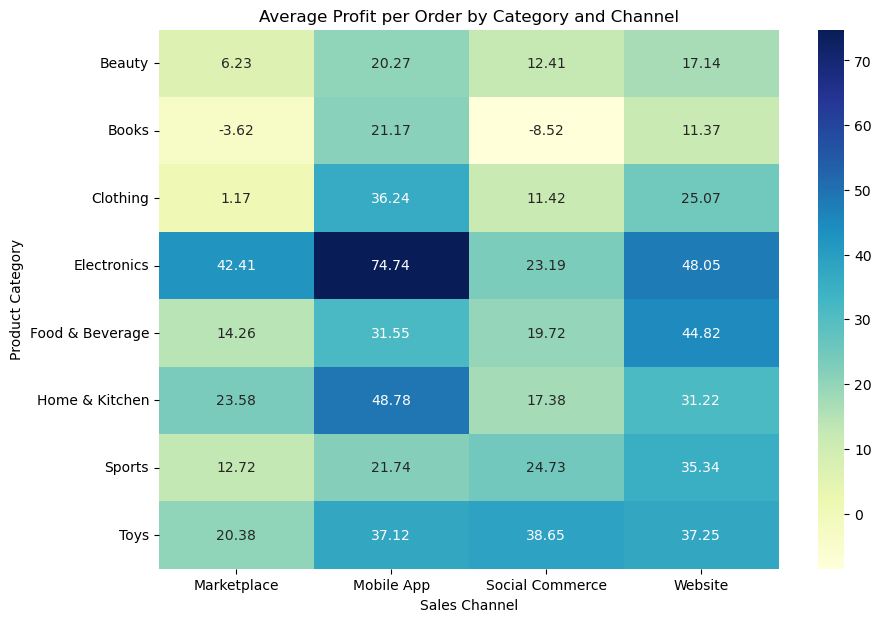

In [37]:
pivot_profit = category_channel.reset_index().pivot(
    index="primary_category",
    columns="channel",
    values="avg_profit"
)

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot_profit,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Profit per Order by Category and Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Product Category")
plt.show()

In [29]:
category_channel.sort_values(
    "total_profit",
    ascending=False
)

total_orders  avg_profit  total_profit
primary_category channel                                                
Electronics      Mobile App                 78       74.74       5829.82
                 Website                   101       48.05       4853.24
Sports           Website                   121       35.34       4276.33
Toys             Website                   111       37.25       4135.21
Food & Beverage  Website                    87       44.82       3899.30
Clothing         Website                   134       25.07       3359.39
Home & Kitchen   Mobile App                 63       48.78       3073.26
Toys             Mobile App                 75       37.12       2784.09
Electronics      Marketplace                65       42.41       2756.94
Clothing         Mobile App                 69       36.24       2500.53
Food & Beverage  Mobile App                 74       31.55       2335.02
Home & Kitchen   Website                    69       31.22       2154.45
Sports           Mobile App                 95       21.74       2065.19
Books            Mobile App                 77       21.17       1629.78
Beauty           Website                    84       17.14       1439.77
                 Mobile App                 58       20.27       1175.61
Home & Kitchen   Marketplace                45       23.58       1061.19
Books            Website                    88       11.37       1000.77
Toys             Marketplace                48       20.38        978.06
                 Social Commerce            23       38.65        888.89
Food & Beverage  Marketplace                62       14.26        884.10
Sports           Marketplace                52       12.72        661.52
                 Social Commerce            24       24.73        593.59
Electronics      Social Commerce            23       23.19        533.46
Food & Beverage  Social Commerce            24       19.72        473.35
Home & Kitchen   Social Commerce            23       17.38        399.67
Clothing         Social Commerce            30       11.42        342.53
Beauty           Social Commerce            27       12.41        335.08
                 Marketplace                36        6.23        224.42
Clothing         Marketplace                60        1.17         70.03
Books            Marketplace                51       -3.62       -184.73
                 Social Commerce            23       -8.52       -196.03

Electronics sold through Mobile App is the most profitable category-channel combination, generating \\$74.74 average profit per order and \\$5,829.82 total profit. In contrast, Books show substantial channel-level differences: Mobile App generates \\$21.17 average profit per order, while Marketplace and Social Commerce generate negative average profits of \\$-3.62 and $-8.52, respectively.

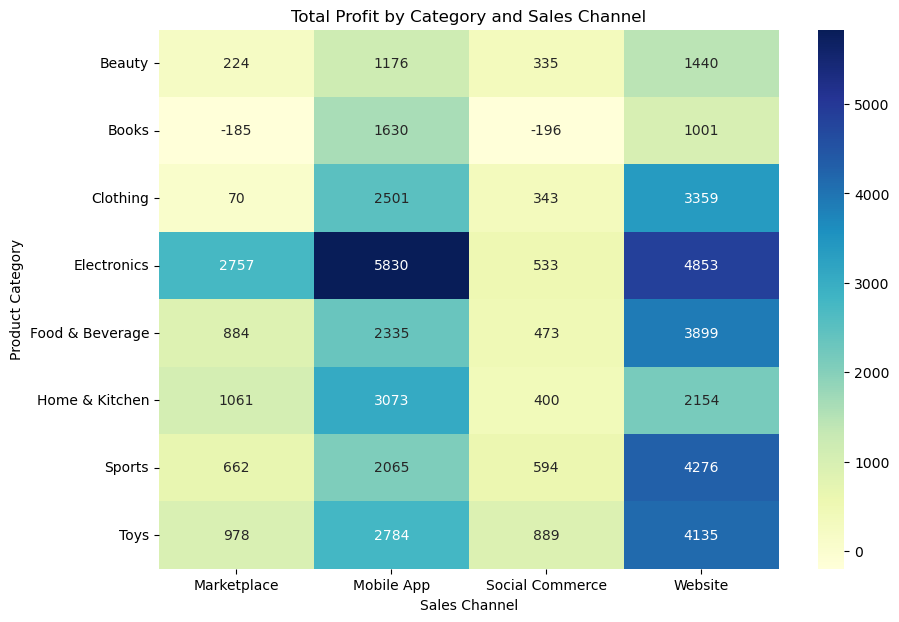

In [38]:
pivot_total = category_channel.reset_index().pivot(
    index="primary_category",
    columns="channel",
    values="total_profit"
)

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot_total,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Total Profit by Category and Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Product Category")
plt.show()